# Presentation

# Packages

In [98]:
from adjustText import adjust_text
from cmapPy.pandasGEXpress import parse
import itertools
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import os
import pandas as pd
import pickle
import random
import seaborn as sns
import scipy.spatial.distance as ssd
import scipy.cluster.hierarchy as sch
from tqdm import tqdm
import umap.umap_ as umap
from upsetplot import generate_counts, plot, from_indicators, UpSet

import torch
from torch.nn import Linear, ReLU, Sequential
import torch.nn.functional as F
from torch_geometric.nn import GINConv, global_add_pool
from torch_geometric.data import Batch
from sklearn.metrics.pairwise import cosine_similarity, pairwise_distances
from torch_geometric.utils import from_networkx

# Directories

In [2]:
INPUT = 'D:/DDesktop/_work/data/canada/input/'
OUTPUT = 'D:/DDesktop/_work/data/canada/output/'

GRAPH = 'D:/DDesktop/_work/graphs/canada/'
CONTEXT = 'D:/DDesktop/_work/graphs/canada/context/'

# Functions

In [3]:
def graph_edge_weights(graph: nx.Graph, modifier: int = 1, report: bool = False) -> list:
    '''
    Extracts edge weight values of a NetworkX graph object to a list. A modifier converts the values for visualisation.
    '''

    weights = [graph[source][target]['weight'] / modifier for source, target, attr in graph.edges(data = True)]

    if report == True:
        num_entries = len(weights)
        print('>> graph_edge_getweights')
        print(f'Weights extracted for {num_entries:,} edges w/ a modifier of {modifier:,}')
        print()

    return weights

def pickle_load(path: str, report: bool = False):
    '''
    Loads pickled data.
    '''

    with open(path, 'rb') as f:
        data = pickle.load(f)

    if report == True:
        if type(data) == nx.Graph:
            num_nodes = len(data.nodes)
            num_edges = len(data.edges)
            print('>> pickle_load')
            print(f'Pickled graph loaded w/ {num_nodes:,} nodes and {num_edges:,} edges')
            print()
        else:
            print('>> pickle_load')
            print(f'Pickled file loaded')
            print()

    return data

def pickle_save(path: str, data, report: bool = False):
    '''
    Pickles data.
    '''

    with open(path, 'wb') as f:
        pickle.dump(data, f)

    if report == True:
        if type(data) == nx.Graph:
            num_nodes = len(data.nodes)
            num_edges = len(data.edges)
            print('>> pickle_save')
            print(f'Graph w/ {num_nodes:,} nodes and {num_edges:,} edges pickled')
        else:
            print('>> pickle_save')
            print(f'Data pickled')
            print()


# Analysis

In [ ]:
# Load data
df_lincs_perturbagens = pickle_load(OUTPUT + 'df_lincs_perturbagens.pkl')
# Get perturbagen IDs
list_known_names = ['imatinib', 'agatolimod', 'pentoxifylline', 'mefloquine', 'rosiglitazone', 'imiquimod', 'acetaminophen', 'agatolimod sodium']
list_known_ids = [df_lincs_perturbagens['perturbagen_id'][df_lincs_perturbagens['perturbagen_name'] == name].values[0] for name in list_known_names]
# Set mefloquine ID
mefloquine_id = 'BRD-K40645748'

## GIN

### PyG graphs

In [256]:
# Initialise graph list
pyg_graphs = []

# Iterate through files
for graph in tqdm(os.listdir(CONTEXT), desc = 'Converting context graphs to PyG objects', total = len(os.listdir(CONTEXT))):
    
    # Get perturbagen id
    perturbagen_id = graph.split('_')[1]
    
    # Load data
    G = pickle_load(CONTEXT + graph)
    # Iterate through nodes
    for node in G.nodes:
        G.nodes[node]['x'] = [G.nodes[node]['dexp']]
    
    # Convert to PyG object
    pyg = from_networkx(G)
    pyg.x = pyg.x.float()
    # Add perturbagen ID as name
    pyg.name = f'{perturbagen_id}'
    pyg_graphs.append(pyg)

Converting context graphs to PyG objects: 100%|██████████| 255/255 [01:14<00:00,  3.42it/s]


### Embedding

In [257]:
# Define untrained GIN encoder
class GINEncoder(torch.nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        nn1 = Sequential(Linear(1, hidden_dim), ReLU(), Linear(hidden_dim, hidden_dim))
        nn2 = Sequential(Linear(hidden_dim, hidden_dim), ReLU(), Linear(hidden_dim, hidden_dim))
        self.conv1 = GINConv(nn1)
        self.conv2 = GINConv(nn2)
        self.lin = Linear(hidden_dim, hidden_dim)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = global_add_pool(x, batch)
        return self.lin(x)

print('Untrained GIN encoder complete')

# Instantiate model
encoder = GINEncoder()
encoder.eval()

print('Model instantiated')

# Generate embeddings (no training)
embeddings = []
with torch.no_grad():
    for graph in tqdm(pyg_graphs, desc = 'Generating embeddings', total = len(pyg_graphs)):
        batch = torch.zeros(graph.x.size(0), dtype=torch.long)  # single graph batch
        emb = encoder(graph.x, graph.edge_index, batch)
        embeddings.append(emb.squeeze())

# Construct embedding matrix
embedding_matrix = torch.stack(embeddings).numpy()

Untrained GIN encoder complete
Model instantiated


Generating embeddings: 100%|██████████| 255/255 [00:00<00:00, 994.38it/s]


### Cosine similarity

In [ ]:
# Load data
df_lincs_perturbagens = pickle_load(OUTPUT + 'df_lincs_perturbagens.pkl')

# Normalise embedding values
normalised_embeddings = embedding_matrix / np.linalg.norm(embedding_matrix, axis=1, keepdims=True)

print('Embeddings normalised')

# Find the index in pyg_graphs with defined ref_id
ref_idx = next(i for i, g in enumerate(pyg_graphs) if g.name == mefloquine_id)

print('Calculating cosine similarities')

# Get cosine similarities to reference graph
similarity = cosine_similarity([normalised_embeddings[ref_idx]], normalised_embeddings)[0]
# Sort by closest similarity
similarity_sort = similarity.argsort()[::-1]
# Get graph IDs
similar_ids = [pyg_graphs[i].name for i in similarity_sort]
# Convert to dataframe
df_cosine = pd.DataFrame(similar_ids, columns = ['perturbagen_id'])
# Merge
df_cosine = pd.merge(df_cosine, df_lincs_perturbagens, on = 'perturbagen_id', how = 'left')
# Show data
df_cosine.head(6)

In [ ]:
plt.hist(similarity)

In [260]:
#q1 = similarity.quantile(0.25)
q1 = np.quantile(similarity, 0.25)
#q3 = similarity.quantile(0.75)
q3 = np.quantile(similarity, 0.75)
iqr = q3 - q1
threshold = q3 + (1.5 * iqr)
print(threshold)

1.130263


In [ ]:
df_cosine.tail(11)

### Centered

In [292]:
# Subtract mean vector and center matrix
centered = embedding_matrix - embedding_matrix.mean(axis=0, keepdims=True)
# Normalise centered values
centered = centered / np.linalg.norm(centered, axis=1, keepdims=True)

# Find the index in pyg_graphs with defined ref_id
ref_idx = next(i for i, g in enumerate(pyg_graphs) if g.name == mefloquine_id)

# Calculate cosine similarity
sims = cosine_similarity([centered[ref_idx]], centered)[0]
# Sort values 
sims_sort = np.sort(sims)[::-1]
# Sort by closest similarity
similarity = sims.argsort()[::-1]
# Get graph IDs
similar_ids = [pyg_graphs[i].name for i in similarity]
# Convert to dataframe
df_centered = pd.DataFrame(similar_ids, columns = ['perturbagen_id'])
# Merge
df_centered = pd.merge(df_centered, df_lincs_perturbagens, on = 'perturbagen_id', how = 'left')
# Add column
df_centered['value'] = sims_sort
# Show data
df_centered[df_centered['value'] >= 0.85]

,perturbagen_id,perturbagen_name,value
0,BRD-K40645748,mefloquine,1.000000
1,BRD-K18163752,BRD-K18163752,0.968069
2,BRD-A77299732,salubrinal,0.943013
3,BRD-A52771319,BRD-A52771319,0.932453
4,BRD-A88282067,delcorine,0.926133
5,BRD-K92723993,imatinib,0.922851
6,BRD-A14566392,scopolamine,0.913290
7,BRD-K97181089,amiloride,0.904890
8,BRD-K56047318,RHC-80267,0.883630
9,BRD-K56509348,BMS-182874,0.882738


In [293]:
df_centered.tail(10)

,perturbagen_id,perturbagen_name,value
245,BRD-K32795028,1-benzylimidazole,-0.840469
246,BRD-A75478957,PD-166793,-0.840993
247,BRD-K57309821,BRD-K57309821,-0.847555
248,BRD-K76600340,nicotinyl-alcohol-tartrate,-0.892003
249,BRD-K56392985,BRD-K56392985,-0.894844
250,BRD-K75430629,BRD-K75430629,-0.902944
251,BRD-K99705204,MW-A1-2,-0.917160
252,BRD-K03552198,BRD-K03552198,-0.925843
253,BRD-K16234721,ARG-CSC2-23,-0.930949
254,BRD-K19049172,ST-4070043,-0.942298


### Euclidean distance

In [274]:
# Compute Euclidean distances
distances = pairwise_distances(embedding_matrix, metric = 'euclidean')

# Find the index in pyg_graphs with defined ref_id
ref_idx = next(i for i, g in enumerate(pyg_graphs) if g.name == mefloquine_id)

# Get closest graphs
distances = distances[ref_idx].argsort()
# Get graph IDs
distances_ids = [pyg_graphs[i].name for i in distances]
# Convert to dataframe
df_distances = pd.DataFrame(distances_ids, columns = ['perturbagen_id'])
# Merge
df_distances = pd.merge(df_distances, df_lincs_perturbagens, on = 'perturbagen_id', how = 'left')
# Show data
df_distances.head(6)

,perturbagen_id,perturbagen_name
0,BRD-K40645748,mefloquine
1,BRD-K18163752,BRD-K18163752
2,BRD-A77299732,salubrinal
3,BRD-A88282067,delcorine
4,BRD-K92723993,imatinib
5,BRD-M47793593,picrotoxin


In [23]:
df_distances.tail(5)

,perturbagen_id,perturbagen_name
20,BRD-K51608872,BRD-K51608872
21,BRD-K47917680,BRD-K47917680
22,BRD-K96274284,UGISS-451
23,BRD-A82238138,budesonide
24,BRD-A54845972,dihydroergotamine


## Visualisation

### uMAP

#### Cosine Similarity

c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



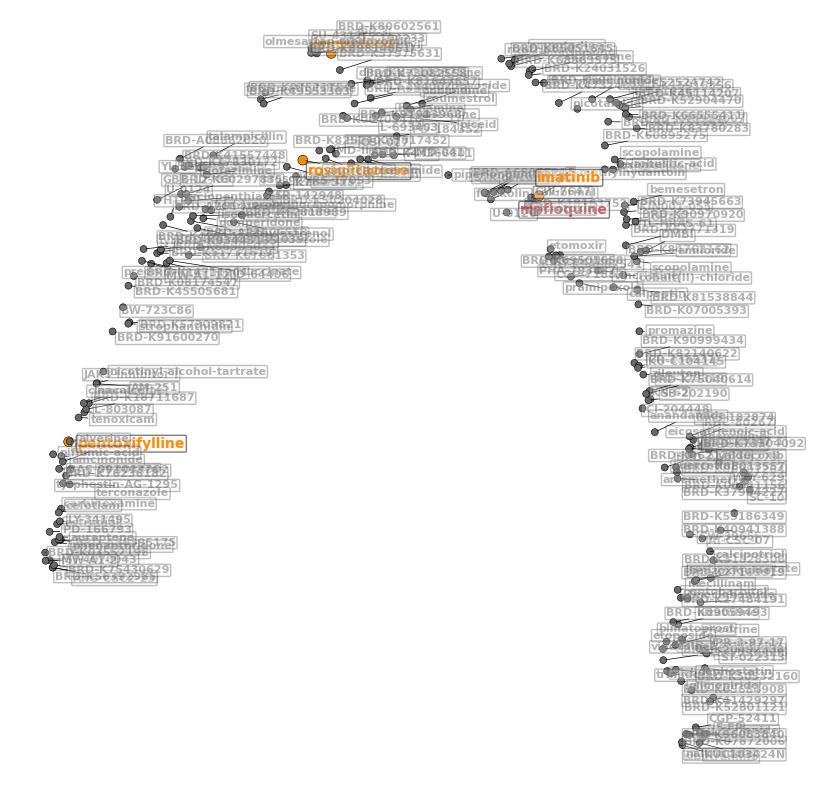

In [ ]:
# Load data
df_lincs_perturbagens = pickle_load(OUTPUT + 'df_lincs_perturbagens.pkl')

# Normalise embedding values
normalised_embeddings = embedding_matrix / np.linalg.norm(embedding_matrix, axis=1, keepdims=True)

# Instantiate model
reducer = umap.UMAP(n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(normalised_embeddings)
graph_ids = [g.name for g in pyg_graphs]
# Convert to dataframe
df_test = pd.DataFrame(embedding_2d, columns = ['x', 'y'])
df_test['perturbagen_id'] = graph_ids
# Merge
df_test = pd.merge(df_test, df_lincs_perturbagens, on = 'perturbagen_id', how = 'left')

# Set colors
colors = ['indianred' if g.name == mefloquine_id else 'darkorange' if g.name in list_known_ids else 'dimgrey' for g in pyg_graphs]
sizes = [100 if g.name == mefloquine_id else 50 if g.name in list_known_ids else 25 for g in pyg_graphs]

plt.figure(figsize=(10, 10))
plt.axis('off')
sns.scatterplot(df_test, x = 'x', y = 'y', c = colors, edgecolors = 'black', s = sizes);

# Label styling
mef_style = {
    'fontsize': 10,
    'weight' : 'bold',
    'color': 'indianred',
    'bbox': {
        'facecolor': 'whitesmoke',
        'alpha': 0.5,
        'edgecolor': 'black',
        'boxstyle': 'round,pad=0.1'
    }
}

known_style = {
    'fontsize': 10,
    'weight' : 'bold',
    'color': 'darkorange',
    'bbox': {
        'facecolor': 'whitesmoke',
        'alpha': 0.5,
        'edgecolor': 'black',
        'boxstyle': 'round,pad=0.1'
    }
}

other_style = {
    'fontsize': 8,
    'alpha' : 0.5,
    'weight' : 'bold',
    'color': 'dimgrey',
    'bbox': {
        'facecolor': 'whitesmoke',
        'alpha': 0.25,
        'edgecolor': 'black',
        'boxstyle': 'round,pad=0.1'
    }
}

texts = []
for id in pd.unique(df_test['perturbagen_id']):
    df_slice = df_test[df_test['perturbagen_id'] == id]
    x, y = df_slice['x'].values[0], df_slice['y'].values[0]
    label = df_slice['perturbagen_name'].values[0]
    if id == mefloquine_id:
        texts.append(plt.text(x, y, label, **mef_style));
    elif id in list_known_ids:
        texts.append(plt.text(x, y, label, **known_style));
    elif id is 1-benzylimidazole
    else:
        texts.append(plt.text(x, y, label, **other_style));
    
adjust_text(texts,
            arrowprops=dict(arrowstyle='-', color='black', lw = 0.5),
            expand = (1.5,1.5), force_explode = (0.5, 0.5));
plt.show()

#### Centered

c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



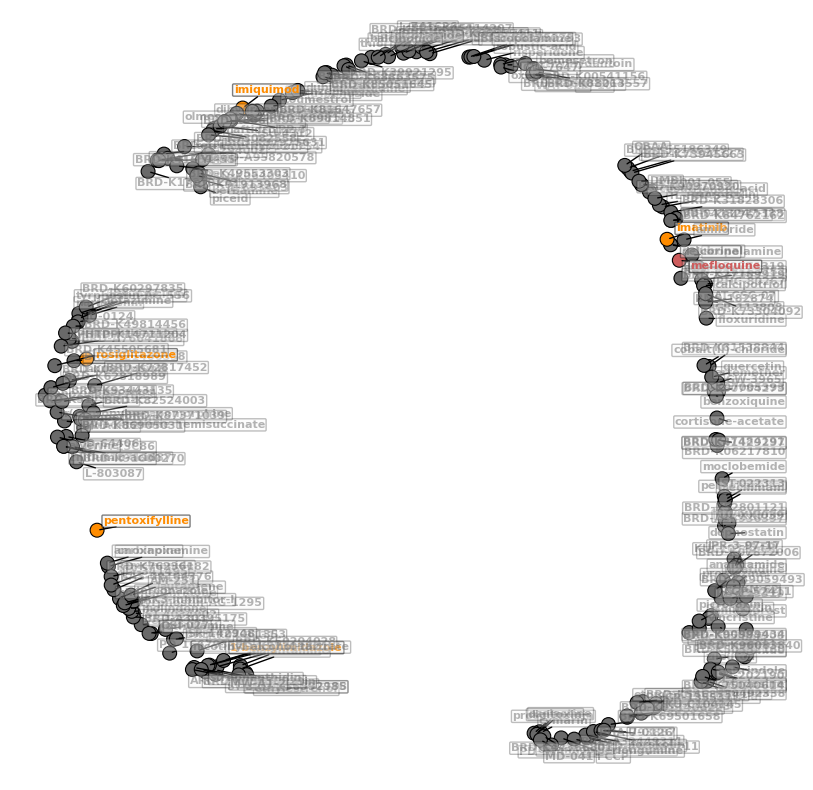

In [294]:
# Load data
df_lincs_perturbagens = pickle_load(OUTPUT + 'df_lincs_perturbagens.pkl')

# Normalise embedding values
#normalised_embeddings = embedding_matrix / np.linalg.norm(embedding_matrix, axis=1, keepdims=True)

# Subtract mean vector and center matrix
centered = embedding_matrix - embedding_matrix.mean(axis=0, keepdims=True)
# Normalise centered values
normalised_embeddings = centered / np.linalg.norm(centered, axis=1, keepdims=True)

# Instantiate model
reducer = umap.UMAP(n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(normalised_embeddings)
graph_ids = [g.name for g in pyg_graphs]
# Convert to dataframe
df_test = pd.DataFrame(embedding_2d, columns = ['x', 'y'])
df_test['perturbagen_id'] = graph_ids
# Merge
df_test = pd.merge(df_test, df_lincs_perturbagens, on = 'perturbagen_id', how = 'left')

# Set colors
colors = ['indianred' if g.name == mefloquine_id else 'darkorange' if g.name in list_known_ids else 'dimgrey' for g in pyg_graphs]

plt.figure(figsize=(10, 10))
plt.axis('off')
sns.scatterplot(df_test, x = 'x', y = 'y', c = colors, edgecolors = 'black', s = 100);

# Label styling
mef_style = {
    'fontsize': 8,
    'weight' : 'bold',
    'color': 'indianred',
    'bbox': {
        'facecolor': 'whitesmoke',
        'alpha': 0.5,
        'edgecolor': 'black',
        'boxstyle': 'round,pad=0.1'
    }
}

known_style = {
    'fontsize': 8,
    'weight' : 'bold',
    'color': 'darkorange',
    'bbox': {
        'facecolor': 'whitesmoke',
        'alpha': 0.5,
        'edgecolor': 'black',
        'boxstyle': 'round,pad=0.1'
    }
}

other_style = {
    'fontsize': 8,
    'alpha' : 0.5,
    'weight' : 'bold',
    'color': 'dimgrey',
    'bbox': {
        'facecolor': 'whitesmoke',
        'alpha': 0.25,
        'edgecolor': 'black',
        'boxstyle': 'round,pad=0.1'
    }
}

texts = []
for id in pd.unique(df_test['perturbagen_id']):
    df_slice = df_test[df_test['perturbagen_id'] == id]
    x, y = df_slice['x'].values[0], df_slice['y'].values[0]
    label = df_slice['perturbagen_name'].values[0]
    if id == mefloquine_id:
        texts.append(plt.text(x, y, label, **mef_style));
    elif id in list_known_ids:
        texts.append(plt.text(x, y, label, **known_style));
    elif id == 'BRD-K32795028':
        texts.append(plt.text(x, y, label, **known_style));
    else:
        texts.append(plt.text(x, y, label, **other_style));
    
adjust_text(texts,
            arrowprops=dict(arrowstyle='-', color='black', lw = 1),
            expand = (2,2));
plt.show()

#### Euclidean distance

c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


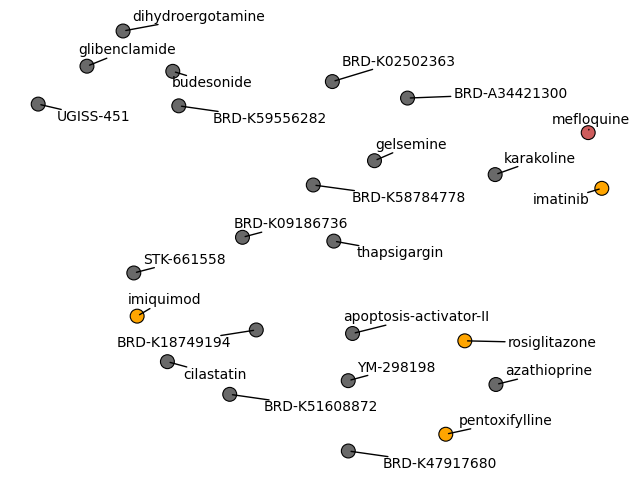

In [73]:
# Load data
df_lincs_perturbagens = pickle_load(OUTPUT + 'df_lincs_perturbagens.pkl')

# # Normalise embedding values
# normalised_embeddings = embedding_matrix / np.linalg.norm(embedding_matrix, axis=1, keepdims=True)

# Instantiate model
reducer = umap.UMAP(n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(embedding_matrix)
graph_ids = [g.name for g in pyg_graphs]
# Convert to dataframe
df_test = pd.DataFrame(embedding_2d, columns = ['x', 'y'])
df_test['perturbagen_id'] = graph_ids
# Merge
df_test = pd.merge(df_test, df_lincs_perturbagens, on = 'perturbagen_id', how = 'left')

# Set colors
colors = ['indianred' if g.name == mefloquine_id else 'orange' if g.name in list_known_ids else 'dimgrey' for g in pyg_graphs]

plt.figure(figsize=(8, 6))
plt.axis('off')
sns.scatterplot(df_test, x = 'x', y = 'y', c = colors, edgecolors = 'black', s = 100);

texts = []
for id in pd.unique(df_test['perturbagen_id']):
    df_slice = df_test[df_test['perturbagen_id'] == id]
    x, y = df_slice['x'].values[0], df_slice['y'].values[0]
    label = df_slice['perturbagen_name'].values[0]
    texts.append(plt.text(x, y, label));
    
adjust_text(texts,
            arrowprops=dict(arrowstyle='-', color='black', lw = 1),
            expand = (1.75,1.75));
plt.show()

## Absolute differences

In [102]:
# Load data
df_lincs_perturbagens = pickle_load(OUTPUT + 'df_lincs_perturbagens.pkl')

# Intialise dataframe
df_diff = pd.DataFrame()

# Iterate through files
for graph in tqdm(os.listdir(CONTEXT), desc = 'Extracting expression values', total = len(os.listdir(CONTEXT))):
    
    # Get perturbagen id
    perturbagen_id = graph.split('_')[1]
    
    # Load data
    G = pickle_load(CONTEXT + graph)

    # Extract values
    dexp = [(node, G.nodes[node]['dexp']) for node in G.nodes]
    # Convert to dataframe
    df_dexp = pd.DataFrame(dexp, columns = ['node', 'dexp'])
    # Add perturbagen ID column
    df_dexp['perturbagen_id'] = perturbagen_id
    # Merge with df_lincs_perturbagens
    df_dexp = pd.merge(df_dexp, df_lincs_perturbagens, on = 'perturbagen_id', how = 'left')
    # Concatenate
    df_diff = pd.concat([df_diff, df_dexp])

# Pivot
df_diff = pd.pivot(df_diff[['perturbagen_id', 'node', 'dexp']], index = 'node', columns = 'perturbagen_id', values = 'dexp')
# Define dataframe
df_abs = df_diff[[mefloquine_id]].copy()
# Get remaining columns
list_columns = [column for column in df_diff.columns if column != mefloquine_id]

# Iterate through columns
for column in tqdm(list_columns, desc = 'Calculating absolute difference', total = len(list_columns)):
    df_abs[column] = (df_abs[mefloquine_id] - df_diff[column]).abs()

# Drop mefloquine column
df_abs.drop(columns = [mefloquine_id], inplace = True)

# Show data
df_abs.head()

Extracting expression values:   0%|          | 0/25 [00:00<?, ?it/s]

Calculating absolute difference: 100%|██████████| 24/24 [00:00<00:00, 3721.93it/s]


perturbagen_id,BRD-A17535965,BRD-A34421300,BRD-A43849199,BRD-A54845972,BRD-A82238138,BRD-A90311807,BRD-A97437073,BRD-K02502363,BRD-K09186736,BRD-K15164005,...,BRD-K36927236,BRD-K47917680,BRD-K51608872,BRD-K57569181,BRD-K58784778,BRD-K59556282,BRD-K59650319,BRD-K69023402,BRD-K92723993,BRD-K96274284
node,,,,,,,,,,,,,,,,,,,,,
ABCB6,1.526952,1.180024,2.188705,0.331692,1.771642,0.222355,1.775782,1.639664,1.727686,1.256863,...,1.829606,0.830379,0.799019,0.793527,1.988364,0.243261,0.914301,1.437881,1.326165,0.433834
ABCC5,0.037456,0.013024,0.445489,9.177466,2.853546,0.165170,0.659157,0.066922,1.485414,0.210458,...,0.700544,1.299665,1.503235,0.088211,3.218285,0.056075,0.497022,0.394586,1.757055,3.651777
ABCF1,1.269906,1.401129,0.931434,1.401666,0.888402,1.856958,0.933133,1.112608,1.254653,0.275321,...,0.905328,1.277360,0.391658,0.061213,2.125990,1.295926,0.810089,1.630920,1.291132,0.394031
ABCF3,0.397323,0.469934,1.295103,0.568010,1.114727,1.305336,1.548055,1.179843,0.873104,0.004887,...,0.293929,1.429587,1.122422,1.232742,0.523276,0.416999,1.947700,1.421263,1.259449,1.035874
ABHD4,0.977585,0.315253,3.492848,6.016291,0.961078,0.387400,1.044387,0.355253,0.458658,1.502220,...,0.843270,0.904133,0.522628,1.077245,0.468889,0.089419,0.310463,0.988174,1.141702,1.337287


In [111]:
for column in df_plot.columns:
    print(column, df_lincs_perturbagens['perturbagen_name'][df_lincs_perturbagens['perturbagen_id'] == column].values[0])

    df_plot.sort_values(by = column, ascending = False, inplace = True)
    print(df_plot.index.values[0:5])

BRD-K92723993 imatinib
['HMOX1' 'DDIT4' 'PTPRK' 'RNH1' 'RFC2']
BRD-K57569181 pentoxifylline
['HMOX1' 'DDIT4' 'ADGRE5' 'SESN1' 'DNAJC15']
BRD-A97437073 rosiglitazone
['TLR4' 'DDIT4' 'CCDC86' 'CEBPA' 'PPARD']
BRD-K26657438 imiquimod
['HMOX1' 'HMGCS1' 'DDIT4' 'RGS2' 'DDX42']


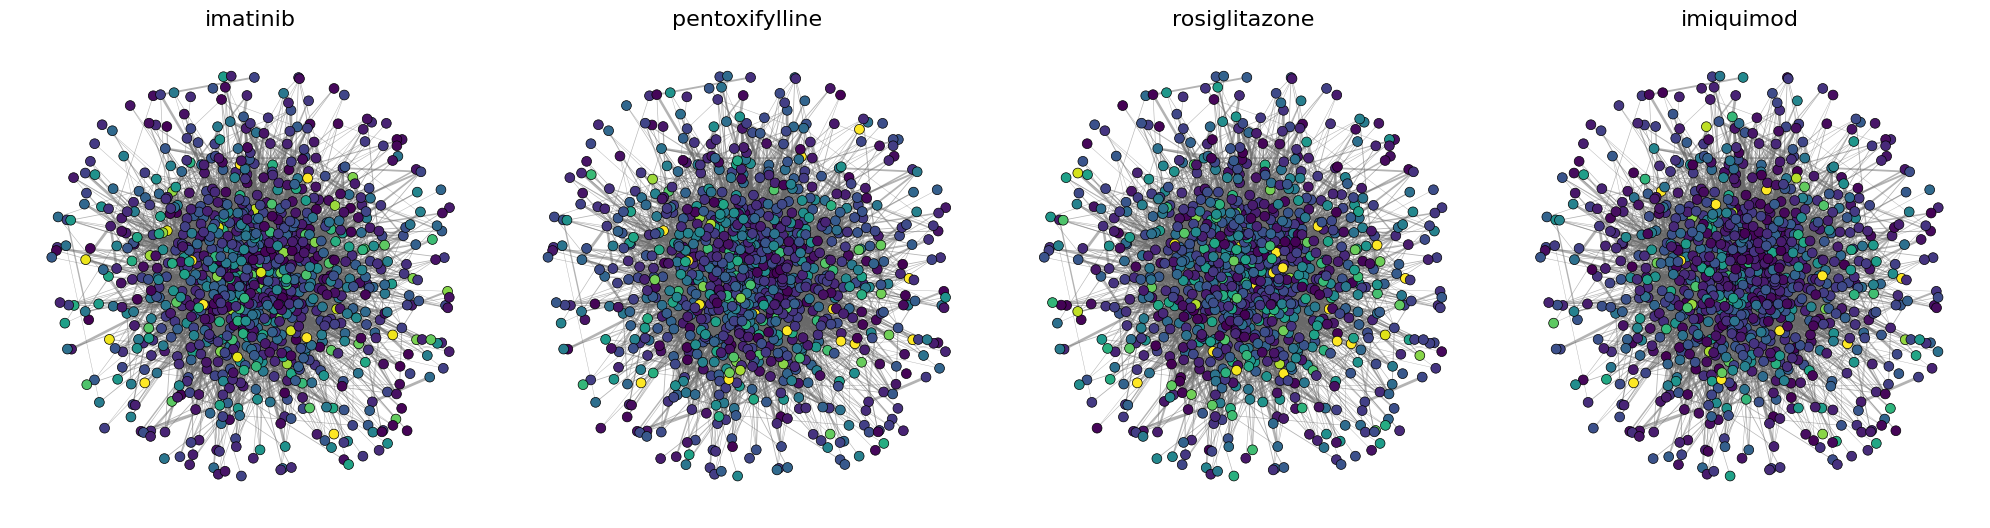

In [119]:
# Load data
df_lincs_perturbagens = pickle_load(OUTPUT + 'df_lincs_perturbagens.pkl')

# Isolate known IDs
df_plot = df_abs[list_known_ids].copy()

# Load reference graph
graph_mef = pickle_load(CONTEXT + 'HT29_BRD-K40645748_10_6H.pkl')
# Generate positional data
pos = nx.spring_layout(graph_mef, k = 2.5)
# Get edge weights
weights = graph_edge_weights(graph_mef, modifier = 500)
# Get node degrees
degrees = [nx.degree(graph_mef, node) * 2 for node in graph_mef.nodes]
# Get nodelist
nodelist = [node for node in graph_mef.nodes]

# Get sorted_abs_names
list_abs_sorted_names = [df_lincs_perturbagens['perturbagen_name'][df_lincs_perturbagens['perturbagen_id'] == id].values[0] for id in list_known_ids]

# Initialise plot
fig, axes = plt.subplots(1, 4, figsize = (20,40))
plt.subplots_adjust(wspace = 0.05, hspace = 0.05)

for idx, (id, label, ax) in enumerate(zip(list_known_ids, list_abs_sorted_names, axes.flat)):

    # Load graph
    G = pickle_load(CONTEXT + f'HT29_{id}_10_6H.pkl')

    # Get abs values for perturbagen
    df_attr = df_plot[[id]]
    # Convert to dictionary
    df_attr_dict = df_attr.to_dict(orient = 'index')
    # Assign node attributes
    nx.set_node_attributes(G, df_attr_dict)
    # Get attribute values
    list_attr = [G.nodes[node][id] for node in G.nodes]

    ax.axis('off')
    ax.set_aspect('equal')

    # Draw edges
    nx.draw_networkx_edges(graph_mef, pos = pos, width = weights, edge_color = 'dimgrey', alpha = 0.5, ax = ax)
    # Draw nodes
    nx.draw_networkx_nodes(G, pos = pos, node_size = 50, node_color = list_attr, cmap = 'viridis', vmax = 4, edgecolors = 'black', linewidths = 0.5, ax = ax)
    # Set title
    ax.set_title(label, fontsize = 16)

plt.tight_layout()
plt.show()

In [150]:
old = df_plot.columns
new = [df_lincs_perturbagens['perturbagen_name'][df_lincs_perturbagens['perturbagen_id'] == name].values[0] for name in old]
for old_name, new_name in zip(old, new):
    df_plot.rename(columns = {old_name : new_name}, inplace = True)

In [148]:
df_plot = df_diff[list_known_ids].copy()
df_plot.head()

perturbagen_id,BRD-K92723993,BRD-K57569181,BRD-A97437073,BRD-K26657438
node,,,,
ABCB6,-0.221457,0.311182,-0.671073,-0.646789
ABCC5,1.676742,-0.168524,-0.739470,-0.975303
ABCF1,-0.231597,1.120748,0.126402,0.427142
ABCF3,0.180789,0.154082,0.469395,0.428014
ABHD4,-0.668781,-0.604323,-0.571466,1.540803


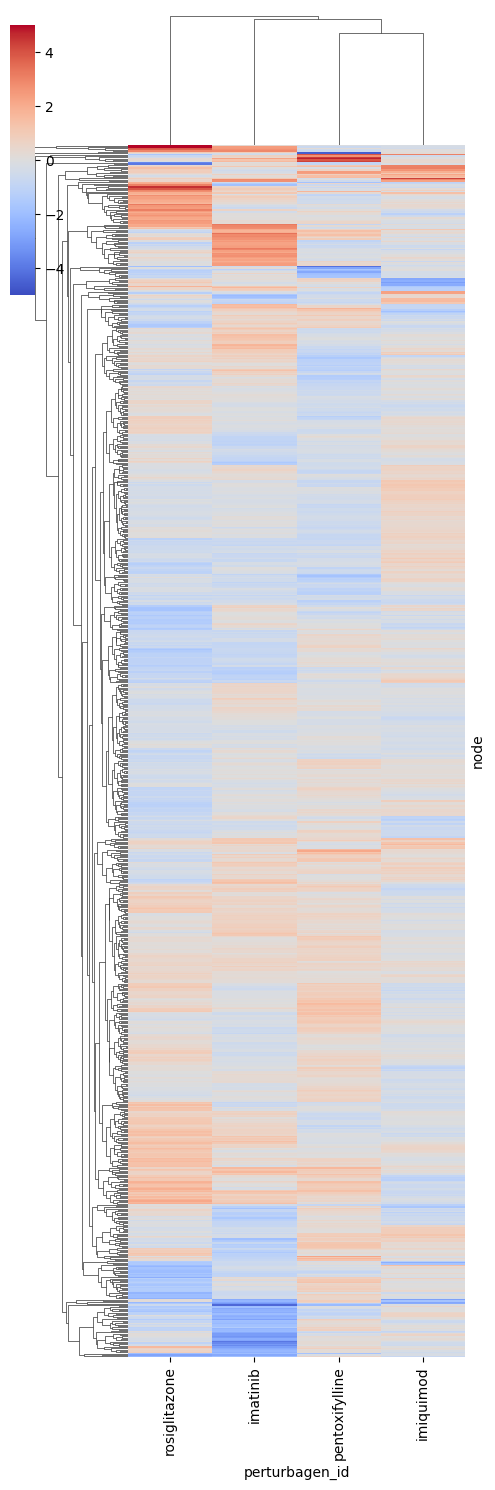

In [152]:
clust = sns.clustermap(df_plot, cmap = 'coolwarm', vmin = -5, vmax = 5, figsize = (5,15),
                       yticklabels = False, dendrogram_ratio = (0.25, 0.1))

In [ ]:
# Get the clustered order of rows and columns
row_order = clust.dendrogram_row.reordered_ind
col_order = clust.dendrogram_col.reordered_ind

# Reorder the DataFrame
df_clustered = df_plot.iloc[row_order, col_order]

df_clustered.head(50)

In [173]:
abs_sum = df_abs.sum().sort_values().index
df_sum = pd.DataFrame(abs_sum, columns = ['perturbagen_id'])
df_sum = pd.merge(df_sum, df_lincs_perturbagens, on = 'perturbagen_id', how = 'left')
df_sum

,perturbagen_id,perturbagen_name
0,BRD-K15164005,apoptosis-activator-II
1,BRD-K26657438,imiquimod
2,BRD-K18749194,BRD-K18749194
3,BRD-K36927236,glibenclamide
4,BRD-K02502363,BRD-K02502363
5,BRD-A34421300,BRD-A34421300
6,BRD-K58784778,BRD-K58784778
7,BRD-K09186736,BRD-K09186736
8,BRD-A17535965,gelsemine
9,BRD-K19146323,STK-661558


### MOA

In [206]:
import pyarrow.parquet as pq

table = pq.read_table(INPUT + 'moa.snappy.parquet')
df = table.to_pandas()  # optional: convert to pandas DataFrame

# Assert data type
df['chemblIds'] = df['chemblIds'].astype(str)
df['targets'] = df['targets'].astype(str)

# Format
for symbol in ['[', ']', '\'']:
    df['chemblIds'] = df['chemblIds'].str.replace(symbol, '')
    df['targets'] = df['targets'].str.replace(symbol, '')

# Expand
df_expand = df['chemblIds'].str.split(' ', expand = True)
df = pd.concat([df, df_expand], axis = 1)

df.drop(columns = ['chemblIds', 'references', 'targets'], inplace = True)
df = pd.melt(df, id_vars = df.columns[0:4])
df.drop(columns = 'variable', inplace = True)
df.rename(columns = {'value' : 'drug_id'}, inplace = True)
df.head(25)

,actionType,mechanismOfAction,targetName,targetType,drug_id
0,ACTIVATOR,"AMP-activated protein kinase, AMPK activator","AMP-activated protein kinase, AMPK",protein complex group,CHEMBL1551724
1,ACTIVATOR,Acetylcholinesterase activator,Acetylcholinesterase,single protein,CHEMBL748
2,ACTIVATOR,Antithrombin-III activator,Antithrombin-III,single protein,CHEMBL1200644
3,ACTIVATOR,Antithrombin-III activator,Antithrombin-III,single protein,CHEMBL1201414
4,ACTIVATOR,Antithrombin-III activator,Antithrombin-III,single protein,CHEMBL1201448
5,ACTIVATOR,Antithrombin-III activator,Antithrombin-III,single protein,CHEMBL1201460
6,ACTIVATOR,Antithrombin-III activator,Antithrombin-III,single protein,CHEMBL1201476
7,ACTIVATOR,Antithrombin-III activator,Antithrombin-III,single protein,CHEMBL1201513
8,ACTIVATOR,Antithrombin-III activator,Antithrombin-III,single protein,CHEMBL1201534
9,ACTIVATOR,Antithrombin-III activator,Antithrombin-III,single protein,CHEMBL1201657


In [180]:
# Get chembl IDs
list_chembl = list(pd.unique(df_opentargets['drug_id']))
list_chembl

['CHEMBL112',
 'CHEMBL628',
 'CHEMBL941',
 'CHEMBL121',
 'CHEMBL2103792',
 'CHEMBL2103793',
 'CHEMBL1282']

In [210]:
df_filter = df[df['drug_id'].isin(list_chembl)]

df_filter = pd.merge(df_filter, df_opentargets[['drug_id', 'drug_name']], on = 'drug_id', how = 'left')
df_filter.drop_duplicates(inplace = True)
print(len(df_filter))
df_filter.head(10)

13


,actionType,mechanismOfAction,targetName,targetType,drug_id,drug_name
0,AGONIST,Toll-like receptor 7 agonist,Toll-like receptor 7,single protein,CHEMBL1282,imiquimod
1,AGONIST,Toll-like receptor 9 agonist,Toll-like receptor 9,single protein,CHEMBL2103793,agatolimod sodium
2,ANTAGONIST,Adenosine A2 receptor antagonist,Adenosine A2 receptor,protein family,CHEMBL628,pentoxifylline
27,INHIBITOR,"3',5'-cyclic phosphodiesterase inhibitor","3',5'-cyclic phosphodiesterase",protein family,CHEMBL628,pentoxifylline
52,INHIBITOR,Anandamide amidohydrolase inhibitor,Anandamide amidohydrolase,single protein,CHEMBL112,acetaminophen
56,INHIBITOR,Cyclooxygenase inhibitor,Cyclooxygenase,protein family,CHEMBL112,acetaminophen
60,OPENER,Vanilloid receptor opener,Vanilloid receptor,single protein,CHEMBL112,acetaminophen
64,AGONIST,Peroxisome proliferator-activated receptor gam...,Peroxisome proliferator-activated receptor gamma,single protein,CHEMBL121,rosiglitazone
65,AGONIST,Toll-like receptor 9 agonist,Toll-like receptor 9,single protein,CHEMBL2103792,agatolimod
66,INHIBITOR,Bcr/Abl fusion protein,Bcr/Abl fusion protein,chimeric protein,CHEMBL941,imatinib
